# Giai đoạn 1: Xây dựng mô hình dự đoán gian lận quét mặt - Face Anti Spoofing

## Cấu hình

In [1]:
# === CELL 1: CÀI ĐẶT MÔI TRƯỜNG ===
%pip install --upgrade pip --quiet
%pip install torch==2.14.0 torchvision --index-url https://download.pytorch.org/whl/xpu --quiet
print("✅ Hoàn tất kiểm tra và cài đặt thư viện!")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Hoàn tất kiểm tra và cài đặt thư viện!


In [2]:
# === CELL 2: IMPORT THƯ VIỆN & KHỞI TẠO XPU ===
import os
import io
import gc
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import optuna
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Tắt đa luồng nội bộ của OpenCV để tránh xung đột (deadlock) với PyTorch DataLoader workers
cv2.setNumThreads(0)
warnings.filterwarnings("ignore")

# --- Cố định Seed đảm bảo tính tái lập ---
SEED = 42
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        torch.xpu.manual_seed(seed)
        torch.xpu.manual_seed_all(seed)

seed_everything(SEED)

# --- Kiểm tra và cấu hình thiết bị Intel XPU ---
has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if has_xpu:
    DEVICE = torch.device("xpu:0")
    n_xpu = torch.xpu.device_count()
    print(f"✅ Đã phát hiện {n_xpu} thiết bị XPU:")
    for i in range(n_xpu):
        try:
            props = torch.xpu.get_device_properties(i)
            total_mem_gb = getattr(props, "total_memory", 0) / (1024**3)
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)} (Bộ nhớ khả dụng: {total_mem_gb:.2f} GB)")
        except Exception:
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Không phát hiện XPU khả dụng -> Fallback về CPU.")

# --- Bật Mixed Precision (bfloat16) theo thiết kế mới ---
USE_AMP = True if has_xpu else False
AUTOCAST_DEVICE_TYPE = "xpu" if has_xpu else "cpu"
AUTOCAST_DTYPE = torch.bfloat16

print(f"\nPyTorch version   : {torch.__version__}")
print(f"Thiết bị sử dụng  : {DEVICE}")
print(f"Mixed Precision   : {USE_AMP} (dtype={AUTOCAST_DTYPE})")

/home/dainguyen1506/Documents/face-anti-spoofing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đã phát hiện 1 thiết bị XPU:
   - xpu:0 -> Intel(R) Graphics (Bộ nhớ khả dụng: 13.24 GB)

PyTorch version   : 2.14.0+xpu
Thiết bị sử dụng  : xpu:0
Mixed Precision   : True (dtype=torch.bfloat16)


In [3]:
# === CELL 3: CẤU HÌNH HỆ THỐNG & THAM SỐ CHUNG ===
PROJECT_ROOT   = Path("..").resolve()
DATASET_ROOT   = PROJECT_ROOT / "dataset"
MODELS_DIR     = PROJECT_ROOT / "models"
ARTIFACTS_DIR  = PROJECT_ROOT / "checkpoint" / "stage1"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET_SLUG = "faber24/lcc-fasd"

# --- Cấu hình Ảnh & Nhãn ---
IMG_SIZE      = 192        # Điểm ngọt cân bằng giữa chi tiết bề mặt và tốc độ XPU
NUM_CLASSES   = 2          # 0 = spoof (giả mạo), 1 = real (người thật)
LABEL2IDX     = {"spoof": 0, "real": 1}
IDX2LABEL     = {v: k for k, v in LABEL2IDX.items()}

# --- Tối ưu hóa Phần cứng (Máy 16GB RAM + Intel Core Ultra / XPU) ---
NUM_WORKERS            = 4
CPU_THREADS            = 12
CACHE_TRAIN_VAL_IN_RAM = True   # Cache Train + Val (~1.18 GB) vào Shared Tensor; Test đọc từ đĩa
MAX_SAFE_CACHE_MB      = 2500   # Ngưỡng an toàn tối đa cho RAM 16GB
USE_CHANNELS_LAST      = has_xpu
PIN_MEMORY             = has_xpu

torch.set_num_threads(CPU_THREADS)

# --- Cấu hình Optuna Hyperparameter Tuning (Không dùng SQLite) ---
RUN_OPTUNA_TUNING = False   # Đặt False nếu muốn bỏ qua tuning và đọc thẳng từ BEST_PARAMS_JSON
N_TRIALS          = 20
TUNE_EPOCHS       = 6
TUNE_TIMEOUT_SEC  = None
BEST_PARAMS_JSON  = ARTIFACTS_DIR / "best_params_stage1.json"

# --- Cấu hình Huấn luyện Toàn phần (Full Training) & Checkpoint ---
FULL_EPOCHS             = 50
EARLY_STOP_PATIENCE     = 12
LR_SCHEDULER_PATIENCE   = 3     # Giảm Learning Rate nếu sau 3 epoch mà val_ACER không cải thiện
LR_SCHEDULER_FACTOR     = 0.5   # Mỗi lần giảm sẽ nhân LR với 0.5

RESUME_FULL_TRAIN       = False # False = Train mới từ đầu và ghi đè checkpoint; True = Chạy tiếp từ LATEST
MODEL1_LATEST_CKPT_PATH = MODELS_DIR / "model1_custom_cnn_latest.pt"
MODEL1_BEST_CKPT_PATH   = MODELS_DIR / "model1_custom_cnn_best.pt"
HISTORY_CSV_PATH        = ARTIFACTS_DIR / "train_history_stage1.csv"

print("✅ Cấu hình hệ thống sẵn sàng!")
print(f"   - DATASET_ROOT           : {DATASET_ROOT}")
print(f"   - MODELS_DIR             : {MODELS_DIR}")
print(f"   - ARTIFACTS_DIR          : {ARTIFACTS_DIR}")
print(f"   - CACHE_TRAIN_VAL_IN_RAM : {CACHE_TRAIN_VAL_IN_RAM}")
print(f"   - Channels-last / PinMem : {USE_CHANNELS_LAST} / {PIN_MEMORY}")

✅ Cấu hình hệ thống sẵn sàng!
   - DATASET_ROOT           : /home/dainguyen1506/Documents/face-anti-spoofing/dataset
   - MODELS_DIR             : /home/dainguyen1506/Documents/face-anti-spoofing/models
   - ARTIFACTS_DIR          : /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage1
   - CACHE_TRAIN_VAL_IN_RAM : True
   - Channels-last / PinMem : True / True


In [4]:
# === CELL 4: KIỂM TRA DỮ LIỆU LCC-FASD & LẬP DANH SÁCH MẪU ===
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def split_dirs_for(root: Path):
    return {
        "train": root / "LCC_FASD_training",
        "val":   root / "LCC_FASD_development",
        "test":  root / "LCC_FASD_evaluation",
    }

def count_images(folder: Path) -> int:
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS) if folder.is_dir() else 0

def split_ready(split_dir: Path) -> bool:
    return count_images(split_dir / "real") > 0 and count_images(split_dir / "spoof") > 0

def find_lcc_fasd_root():
    candidates = [DATASET_ROOT / "LCC_FASD", DATASET_ROOT]
    if DATASET_ROOT.exists():
        candidates += [p.parent for p in DATASET_ROOT.rglob("LCC_FASD_training") if p.is_dir()]
    seen = set()
    for root in candidates:
        root = root.resolve()
        if root in seen:
            continue
        seen.add(root)
        split_dirs = split_dirs_for(root)
        if all(split_ready(d) for d in split_dirs.values()):
            return root, split_dirs
    root = (DATASET_ROOT / "LCC_FASD").resolve()
    return root, split_dirs_for(root)

LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

if not dataset_ready:
    print(f"⚠️ Chưa tìm thấy LCC-FASD tại {LCC_FASD_ROOT} -> Đang tải từ Kaggle...")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(KAGGLE_DATASET_SLUG, path=str(DATASET_ROOT), unzip=True, quiet=False)
    LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
    dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

assert dataset_ready, f"❌ Dữ liệu LCC-FASD vẫn chưa đầy đủ tại {DATASET_ROOT}."

def list_samples(split_dir: Path):
    samples = []
    for label_name in ("spoof", "real"):
        label_idx = LABEL2IDX[label_name]
        label_dir = split_dir / label_name
        samples.extend(
            (str(p), label_idx)
            for p in sorted(label_dir.rglob("*"))
            if p.suffix.lower() in IMG_EXTS
        )
    return samples

train_samples = list_samples(SPLIT_DIRS["train"])
val_samples   = list_samples(SPLIT_DIRS["val"])
test_samples  = list_samples(SPLIT_DIRS["test"])

print(f"✅ Đã tìm thấy LCC-FASD tại: {LCC_FASD_ROOT}\n")
print("=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===")
for name, s_list in [("Train", train_samples), ("Val", val_samples), ("Test", test_samples)]:
    cnt = Counter(label for _, label in s_list)
    n_real, n_spoof = cnt.get(1, 0), cnt.get(0, 0)
    ratio = n_spoof / max(n_real, 1)
    print(f"  {name:5s}: {len(s_list):6d} ảnh | Real (1) = {n_real:5d} ({n_real/len(s_list)*100:5.1f}%) | Spoof (0) = {n_spoof:5d} ({n_spoof/len(s_list)*100:5.1f}%) | Tỉ lệ Spoof/Real = {ratio:.2f}:1")

✅ Đã tìm thấy LCC-FASD tại: /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD

=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===
  Train:   8299 ảnh | Real (1) =  1223 ( 14.7%) | Spoof (0) =  7076 ( 85.3%) | Tỉ lệ Spoof/Real = 5.79:1
  Val  :   2948 ảnh | Real (1) =   405 ( 13.7%) | Spoof (0) =  2543 ( 86.3%) | Tỉ lệ Spoof/Real = 6.28:1
  Test :   7580 ảnh | Real (1) =   314 (  4.1%) | Spoof (0) =  7266 ( 95.9%) | Tỉ lệ Spoof/Real = 23.14:1


## Nạp Cache RAM đa luồng, Thiết lập Augmentation & Class `FASDataset`

In [5]:
# === CELL 5: TIỀN NẠP CACHE RAM ĐA LUỒNG, AUGMENTATION & DATASET ===
from concurrent.futures import ThreadPoolExecutor

def decode_and_resize_single(args):
    path, img_size = args
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

def build_shared_ram_cache(samples, img_size: int, desc: str = "Cache"):
    """Nạp toàn bộ danh sách ảnh vào Shared Memory Tensor (uint8) dùng đa luồng."""
    n = len(samples)
    est_mb = (n * img_size * img_size * 3) / (1024 ** 2)
    print(f"⏳ Đang nạp {desc} ({n} ảnh @ {img_size}x{img_size}) vào Shared RAM (~{est_mb:.1f} MB)...")
    t0 = time.time()

    # Cấp phát khối bộ nhớ chia sẻ liên tục (Shared Memory) để các DataLoader workers dùng chung không tốn thêm RAM
    shared_tensor = torch.empty((n, img_size, img_size, 3), dtype=torch.uint8).share_memory_()
    shared_np = shared_tensor.numpy()

    tasks = [(path, img_size) for path, _ in samples]
    with ThreadPoolExecutor(max_workers=CPU_THREADS) as executor:
        for idx, img in enumerate(tqdm(executor.map(decode_and_resize_single, tasks), total=n, desc=desc, leave=False)):
            shared_np[idx] = img

    print(f"✅ Hoàn tất nạp {desc} trong {time.time() - t0:.2f}s! (Chiếm {est_mb:.1f} MB RAM cố định)")
    return shared_tensor

# Kiểm tra dung lượng trước khi Cache Train + Val
est_train_val_mb = (len(train_samples) + len(val_samples)) * (IMG_SIZE ** 2) * 3 / (1024 ** 2)
if CACHE_TRAIN_VAL_IN_RAM and est_train_val_mb <= MAX_SAFE_CACHE_MB:
    train_ram_cache = build_shared_ram_cache(train_samples, IMG_SIZE, desc="Train Split")
    val_ram_cache   = build_shared_ram_cache(val_samples, IMG_SIZE, desc="Val Split")
else:
    print("⚠️ Bỏ qua Cache RAM -> Đọc trực tiếp từ ổ cứng.")
    train_ram_cache = None
    val_ram_cache   = None

⏳ Đang nạp Train Split (8299 ảnh @ 192x192) vào Shared RAM (~875.3 MB)...


✅ Hoàn tất nạp Train Split trong 9.22s! (Chiếm 875.3 MB RAM cố định)
⏳ Đang nạp Val Split (2948 ảnh @ 192x192) vào Shared RAM (~310.9 MB)...


✅ Hoàn tất nạp Val Split trong 3.39s! (Chiếm 310.9 MB RAM cố định)


In [6]:
class FASDataset(Dataset):
    """Dataset Face Anti-Spoofing hỗ trợ đọc từ Shared Memory Tensor hoặc ổ cứng."""
    def __init__(self, samples, img_size: int, transform=None, shared_cache: torch.Tensor = None):
        self.samples = samples
        self.img_size = img_size
        self.transform = transform
        self.shared_cache = shared_cache

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if self.shared_cache is not None:
            # Lấy từ Shared RAM và copy nhẹ ra mảng riêng để Albumentations biến đổi an toàn
            img = self.shared_cache[idx].numpy().copy()
        else:
            img = decode_and_resize_single((path, self.img_size))

        if self.transform is not None:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)

# --- Thiết lập chuỗi Augmentation chuyên biệt cho Face Anti-Spoofing ---
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4,
    ),
    # Biến đổi màu sắc và độ sáng giúp chống học vẹt điều kiện ánh sáng môi trường
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.4),
    # Mô phỏng hiện tượng mất nét, nén ảnh qua mạng hoặc nhiễu cảm biến camera
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.ImageCompression(quality_range=(55, 95), p=1.0),
        A.GaussNoise(std_range=(0.01, 0.05), p=1.0),
    ], p=0.35),
    # Che ngẫu nhiên các vùng nhỏ để ép CNN học kết cấu bề mặt toàn cục
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(12, 24),
        hole_width_range=(12, 24),
        fill=0,
        p=0.25,
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_ds = FASDataset(train_samples, IMG_SIZE, transform=train_transform, shared_cache=train_ram_cache)
val_ds   = FASDataset(val_samples,   IMG_SIZE, transform=eval_transform,  shared_cache=val_ram_cache)
test_ds  = FASDataset(test_samples,  IMG_SIZE, transform=eval_transform,  shared_cache=None) # Test đọc từ đĩa để tiết kiệm ~800MB RAM

print(f"\n📦 Khởi tạo Dataset hoàn tất: train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")


📦 Khởi tạo Dataset hoàn tất: train=8299 | val=2948 | test=7580


## Tạo WeightedRandomSampler cân bằng lớp 50/50 & Kiểm tra trực quan Batch

✅ Batch shape : torch.Size([16, 3, 192, 192]) | dtype: torch.float32
✅ Labels (16) : [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0]
⚖️ Tỉ lệ trong Batch: Real (1) = 6/16 | Spoof (0) = 10/16


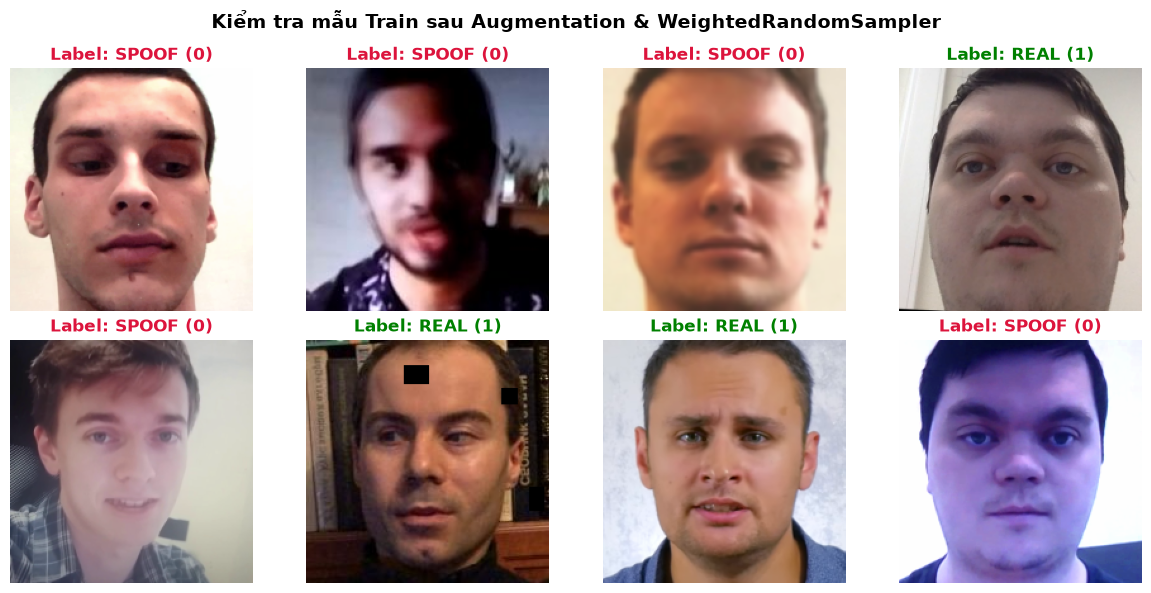

In [7]:
# === CELL 6: TẠO DATALOADER CÂN BẰNG NHÃN & KIỂM TRA TRỰC QUAN 1 BATCH ===
# Tính trọng số lấy mẫu (Sampling Weights) cho tập Train để cân bằng 50% Real - 50% Spoof
train_labels = np.array([label for _, label in train_samples], dtype=np.int64)
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_sample_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = torch.from_numpy(class_sample_weights[train_labels]).double()

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_samples),
    replacement=True,
)

def make_dataloaders(batch_size: int = 64):
    """Hàm tạo bộ DataLoader với batch_size tùy chỉnh (dùng cho cả Optuna và Full Train)."""
    common_kwargs = dict(
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=train_sampler,   # Dùng WeightedRandomSampler thay cho shuffle=True
        drop_last=True,
        **common_kwargs,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )
    return train_loader, val_loader, test_loader

# --- Kiểm tra thử 1 Batch từ train_loader ---
preview_train_loader, _, _ = make_dataloaders(batch_size=16)
imgs_batch, labels_batch = next(iter(preview_train_loader))

n_real_in_batch = (labels_batch == 1).sum().item()
n_spoof_in_batch = (labels_batch == 0).sum().item()
print(f"✅ Batch shape : {imgs_batch.shape} | dtype: {imgs_batch.dtype}")
print(f"✅ Labels (16) : {labels_batch.tolist()}")
print(f"⚖️ Tỉ lệ trong Batch: Real (1) = {n_real_in_batch}/16 | Spoof (0) = {n_spoof_in_batch}/16")

# --- Hiển thị trực quan 8 ảnh đầu tiên trong Batch ---
mean_np = np.array(IMAGENET_MEAN)
std_np  = np.array(IMAGENET_STD)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img_vis = imgs_batch[i].permute(1, 2, 0).numpy()
    img_vis = np.clip(img_vis * std_np + mean_np, 0, 1)
    lbl_idx = labels_batch[i].item()
    lbl_str = IDX2LABEL[lbl_idx].upper()
    color   = "green" if lbl_idx == 1 else "crimson"
    
    ax.imshow(img_vis)
    ax.set_title(f"Label: {lbl_str} ({lbl_idx})", color=color, fontweight="bold")
    ax.axis("off")

plt.suptitle("Kiểm tra mẫu Train sau Augmentation & WeightedRandomSampler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
del preview_train_loader

In [8]:
# === CELL 7: KIẾN TRÚC MẠNG CUSTOM CNN (CDCN-LITE + RESIDUAL + SE-ATTENTION) ===

class Conv2d_CD(nn.Module):
    """
    Central Difference Convolution (Bản tối ưu hóa Fused-Kernel cho XPU).
    Gộp phép trừ sai phân trung tâm trực tiếp vào ma trận trọng số 3x3 trước khi tích chập,
    giúp XPU chỉ cần chạy 1 lần F.conv2d duy nhất (tăng tốc ~35% mà toán học tương đương 100%).
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3,
                 stride: int = 1, padding: int = 1, bias: bool = False, theta: float = 0.7):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size,
                              stride=stride, padding=padding, bias=bias)
        self.theta = theta

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if abs(self.theta) < 1e-6:
            return self.conv(x)
        # Tính tổng trọng số 3x3 và trừ trực tiếp vào điểm tâm (1, 1) của kernel
        w = self.conv.weight
        kernel_diff = w.sum(dim=(2, 3))
        w_fused = w.clone()
        w_fused[:, :, 1, 1] = w[:, :, 1, 1] - self.theta * kernel_diff
        return F.conv2d(x, w_fused, self.conv.bias, self.conv.stride, self.conv.padding,
                        self.conv.dilation, self.conv.groups)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation (Channel Attention) giúp mạng tập trung vào kênh đặc trưng quan trọng."""
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        mid_c = max(channels // reduction, 8)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, mid_c, bias=False),
            nn.SiLU(inplace=True),
            nn.Linear(mid_c, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class ResidualCDBlock(nn.Module):
    """Khối Residual kết hợp Conv2d_CD + BatchNorm + SiLU + SE-Attention."""
    def __init__(self, in_c: int, out_c: int, stride: int = 1, theta: float = 0.7):
        super().__init__()
        self.conv1 = Conv2d_CD(in_c, out_c, kernel_size=3, stride=stride, padding=1, bias=False, theta=theta)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.act   = nn.SiLU(inplace=True)

        self.conv2 = Conv2d_CD(out_c, out_c, kernel_size=3, stride=1, padding=1, bias=False, theta=theta)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.se    = SEBlock(out_c)

        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = self.act(out + residual)
        return out


class CustomFASNet(nn.Module):
    """
    Model 1: Custom CNN thiết kế từ đầu cho Face Anti-Spoofing.
    Tách biệt rõ `extract_features(x)` (Encoder cho Giai đoạn 2 & 3) và `classifier` (Head).
    """
    def __init__(self, base_channels: int = 32, dropout_rate: float = 0.3,
                 theta: float = 0.7, num_classes: int = 2):
        super().__init__()
        self.config = {
            "base_channels": base_channels,
            "dropout_rate": dropout_rate,
            "theta": theta,
            "num_classes": num_classes,
        }
        c1 = base_channels          # 32 hoặc 48
        c2 = base_channels * 2      # 64 hoặc 96
        c3 = base_channels * 4      # 128 hoặc 192
        c4 = base_channels * 8      # 256 hoặc 384
        self.feature_dim = c4 * 2   # Ghép cả AvgPool và MaxPool để giữ trọn đặc trưng cực trị

        # Stem: 192x192 -> 96x96
        self.stem = nn.Sequential(
            Conv2d_CD(3, c1, kernel_size=3, stride=2, padding=1, bias=False, theta=theta),
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True),
        )
        # 4 Stages: 96x96 -> 48x48 -> 24x24 -> 12x12 -> 6x6
        self.stage1 = ResidualCDBlock(c1, c1, stride=1, theta=theta)
        self.stage2 = ResidualCDBlock(c1, c2, stride=2, theta=theta)
        self.stage3 = ResidualCDBlock(c2, c3, stride=2, theta=theta)
        self.stage4 = ResidualCDBlock(c3, c4, stride=2, theta=theta)

        # Dual Pooling Head: Vừa lấy trung bình toàn cục (AvgPool) vừa bắt các điểm lóa/vân mạnh nhất (MaxPool)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, c4, bias=False),
            nn.BatchNorm1d(c4),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(c4, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Trích xuất vector đặc trưng (dùng làm Encoder cho Giai đoạn 2 & 3)."""
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        avg_f = self.avg_pool(x).flatten(1)
        max_f = self.max_pool(x).flatten(1)
        return torch.cat([avg_f, max_f], dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits


# --- Kiểm tra thử Mô hình trên XPU với Channels-Last & bfloat16 ---
test_model = CustomFASNet(base_channels=32, dropout_rate=0.3, theta=0.7, num_classes=NUM_CLASSES).to(DEVICE)
if USE_CHANNELS_LAST:
    test_model = test_model.to(memory_format=torch.channels_last)

dummy_x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
if USE_CHANNELS_LAST:
    dummy_x = dummy_x.to(memory_format=torch.channels_last)

with torch.no_grad(), torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
    dummy_feats  = test_model.extract_features(dummy_x)
    dummy_logits = test_model(dummy_x)

n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"✅ Khởi tạo CustomFASNet thành công trên {DEVICE}!")
print(f"   - Tổng số tham số (Trainable Params) : {n_params:,} (~{n_params*4/(1024**2):.2f} MB FP32)")
print(f"   - Kích thước Embedding (Encoder out) : {dummy_feats.shape}")
print(f"   - Kích thước Logits đầu ra           : {dummy_logits.shape} (dtype={dummy_logits.dtype})")
del test_model, dummy_x, dummy_feats, dummy_logits
if has_xpu:
    torch.xpu.empty_cache()

✅ Khởi tạo CustomFASNet thành công trên xpu:0!
   - Tổng số tham số (Trainable Params) : 1,380,514 (~5.27 MB FP32)
   - Kích thước Embedding (Encoder out) : torch.Size([4, 512])
   - Kích thước Logits đầu ra           : torch.Size([4, 2]) (dtype=torch.bfloat16)


In [9]:
# === CELL 8: HÀM FOCAL LOSS (CÓ LABEL SMOOTHING) & CHỈ SỐ ISO/IEC 30107-3 ===

class FocalLossWithSmoothing(nn.Module):
    """
    Focal Loss kết hợp Label Smoothing và trọng số phạt lớp Real (alpha_real).
    - gamma: Phạt nặng các mẫu khó phân loại (mẫu có xác suất dự đoán đúng thấp).
    - alpha_real: Trọng số ưu tiên cho lớp Real (1) để giảm BPCER.
    - label_smoothing: Làm mượt nhãn để tránh mạng CNN quá tự tin (overconfident).
    """
    def __init__(self, alpha_real: float = 0.6, gamma: float = 2.0, label_smoothing: float = 0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        # Trọng số cho lớp 0 (Spoof) = 1 - alpha_real, lớp 1 (Real) = alpha_real
        self.register_buffer("alpha", torch.tensor([1.0 - alpha_real, alpha_real], dtype=torch.float32))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Chuyển về float32 để tính log_softmax chính xác tuyệt đối ngay cả khi chạy autocast bf16
        logits_fp32 = logits.float()
        num_classes = logits_fp32.size(-1)

        with torch.no_grad():
            smooth_targets = torch.full_like(logits_fp32, self.label_smoothing / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        log_probs = F.log_softmax(logits_fp32, dim=-1)
        probs     = torch.exp(log_probs)

        # Xác suất dự đoán tại đúng lớp mục tiêu
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1.0 - pt).pow(self.gamma)

        # Trọng số lớp alpha tương ứng với từng mẫu
        alpha_t = self.alpha.to(logits_fp32.device).gather(0, targets)

        # Cross-entropy với nhãn đã làm mượt
        ce_loss = -(smooth_targets * log_probs).sum(dim=-1)
        loss = alpha_t * focal_weight * ce_loss
        return loss.mean()


def compute_iso_metrics_at_threshold(y_true: np.ndarray, y_prob_real: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Tính bộ chỉ số chuẩn ISO/IEC 30107-3 tại ngưỡng xác suất `threshold`:
    - Nhãn 0: Spoof (Presentation Attack)
    - Nhãn 1: Real (Bona Fide)
    - APCER = FP / (TN + FP) : Tỷ lệ Spoof bị nhận nhầm là Real
    - BPCER = FN / (TP + FN) : Tỷ lệ Real bị từ chối nhầm là Spoof
    - ACER  = (APCER + BPCER) / 2
    """
    y_pred = (y_prob_real >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    apcer = fp / max(tn + fp, 1)
    bpcer = fn / max(tp + fn, 1)
    acer  = 0.5 * (apcer + bpcer)
    acc   = (tp + tn) / max(tp + tn + fp + fn, 1)

    return {
        "threshold": float(threshold),
        "APCER": float(apcer),
        "BPCER": float(bpcer),
        "ACER": float(acer),
        "ACC": float(acc),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def evaluate_fas_predictions(y_true: np.ndarray, y_prob_real: np.ndarray, fixed_threshold: float = None) -> dict:
    """
    Nếu `fixed_threshold=None` (dùng trên tập Val): Tự động dò trên đường cong ROC để tìm
    ngưỡng tối ưu tại điểm EER (nơi APCER và BPCER cân bằng nhất) rồi tính ACER.
    Nếu truyền `fixed_threshold` (dùng trên tập Test): Áp đúng ngưỡng của tập Val sang để đánh giá khách quan.
    """
    auc = roc_auc_score(y_true, y_prob_real) if len(np.unique(y_true)) > 1 else 0.5

    # Đường cong ROC với pos_label=1 (Real):
    # fpr chính là tỷ lệ Spoof đoán nhầm thành Real (= APCER)
    # fnr = 1 - tpr chính là tỷ lệ Real đoán nhầm thành Spoof (= BPCER)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob_real, pos_label=1)
    fnr = 1.0 - tpr

    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer = float(0.5 * (fpr[eer_idx] + fnr[eer_idx]))
    eer_threshold = float(np.clip(thresholds[eer_idx], 1e-4, 1.0 - 1e-4))

    chosen_thr = eer_threshold if fixed_threshold is None else fixed_threshold
    metrics = compute_iso_metrics_at_threshold(y_true, y_prob_real, threshold=chosen_thr)
    metrics["AUC"] = float(auc)
    metrics["EER"] = float(eer)
    metrics["EER_threshold"] = float(eer_threshold)
    return metrics

print("✅ Đã nạp FocalLossWithSmoothing & Bộ hàm đánh giá chuẩn ISO/IEC 30107-3!")

✅ Đã nạp FocalLossWithSmoothing & Bộ hàm đánh giá chuẩn ISO/IEC 30107-3!


In [10]:
# === CELL 9: VÒNG LẶP TRAIN 1 EPOCH & EVALUATE TỐI ƯU CHO INTEL XPU ===

def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module,
                    optimizer: torch.optim.Optimizer, epoch_desc: str = "Train") -> float:
    model.train()
    running_loss = 0.0
    n_samples = 0

    pbar = tqdm(loader, desc=epoch_desc, leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE, non_blocking=PIN_MEMORY)
        labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)
        if USE_CHANNELS_LAST:
            imgs = imgs.to(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        loss.backward()
        # Chống bùng nổ đạo hàm (Gradient Clipping) giúp mạng hội tụ ổn định hơn
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        n_samples    += bs
        pbar.set_postfix({"loss": f"{running_loss / max(n_samples, 1):.4f}"})

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module,
                   fixed_threshold: float = None, desc: str = "Eval") -> tuple[dict, np.ndarray, np.ndarray]:
    model.eval()
    running_loss = 0.0
    n_samples = 0
    all_probs = []
    all_labels = []

    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=PIN_MEMORY)
        labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)
        if USE_CHANNELS_LAST:
            imgs = imgs.to(memory_format=torch.channels_last)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs_real = F.softmax(logits.float(), dim=-1)[:, 1]

        bs = labels.size(0)
        running_loss += loss.item() * bs
        n_samples    += bs

        all_probs.append(probs_real.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    y_prob_real = np.concatenate(all_probs, axis=0)
    y_true      = np.concatenate(all_labels, axis=0)

    metrics = evaluate_fas_predictions(y_true, y_prob_real, fixed_threshold=fixed_threshold)
    metrics["loss"] = running_loss / max(n_samples, 1)
    return metrics, y_true, y_prob_real

print("✅ Đã định nghĩa xong hàm train_one_epoch & evaluate_model!")

✅ Đã định nghĩa xong hàm train_one_epoch & evaluate_model!


In [11]:
# === CELL 10 (BẢN TỐI ƯU TỐC ĐỘ): OPTUNA VỚI FAST SUBSET SAMPLING ===
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Chỉ lấy 2.560 mẫu cân bằng (50% Real / 50% Spoof) mỗi epoch khi dò Optuna để giảm thời gian 1 epoch xuống ~25 giây!
TUNE_SUBSET_SIZE = 2560
tune_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=TUNE_SUBSET_SIZE,
    replacement=True,
)

def make_tune_dataloaders(batch_size: int = 64):
    common_kwargs = dict(
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )
    tune_train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=tune_sampler,
        drop_last=True,
        **common_kwargs,
    )
    tune_val_loader = DataLoader(
        val_ds,
        batch_size=batch_size * 2,  # Tăng gấp đôi batch_size lúc Val để chấm điểm nhanh hơn
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )
    return tune_train_loader, tune_val_loader


def optuna_objective(trial: optuna.Trial) -> float:
    lr              = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay    = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size      = trial.suggest_categorical("batch_size", [32, 64])
    base_channels   = trial.suggest_categorical("base_channels", [32, 48])
    dropout_rate    = trial.suggest_float("dropout_rate", 0.15, 0.45, step=0.05)
    theta           = trial.suggest_float("theta", 0.4, 0.8, step=0.1)
    focal_gamma     = trial.suggest_float("focal_gamma", 1.0, 2.5, step=0.25)
    alpha_real      = trial.suggest_float("alpha_real", 0.50, 0.65, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.02, 0.10, step=0.02)

    train_loader, val_loader = make_tune_dataloaders(batch_size=batch_size)

    model = CustomFASNet(
        base_channels=base_channels,
        dropout_rate=dropout_rate,
        theta=theta,
        num_classes=NUM_CLASSES,
    ).to(DEVICE)
    if USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)

    criterion = FocalLossWithSmoothing(
        alpha_real=alpha_real,
        gamma=focal_gamma,
        label_smoothing=label_smoothing,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_trial_acer = float("inf")

    for epoch in range(1, TUNE_EPOCHS + 1):
        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer,
            epoch_desc=f"Trial {trial.number:02d} Ep {epoch}/{TUNE_EPOCHS}"
        )
        val_metrics, _, _ = evaluate_model(model, val_loader, criterion, fixed_threshold=None, desc="Val")
        val_acer = val_metrics["ACER"]

        scheduler.step(val_acer)
        if val_acer < best_trial_acer:
            best_trial_acer = val_acer

        trial.report(val_acer, step=epoch)
        if trial.should_prune():
            del model, criterion, optimizer, train_loader, val_loader
            if has_xpu:
                torch.xpu.empty_cache()
            raise optuna.TrialPruned()

    print(f"🔹 Trial {trial.number:02d} hoàn tất | Best Val ACER: {best_trial_acer*100:.2f}% (AUC: {val_metrics['AUC']:.4f}) | Params: bs={batch_size}, ch={base_channels}, lr={lr:.5f}")

    del model, criterion, optimizer, train_loader, val_loader
    if has_xpu:
        torch.xpu.empty_cache()
    return best_trial_acer


if RUN_OPTUNA_TUNING or not BEST_PARAMS_JSON.exists():
    print(f"🚀 Bắt đầu chạy Fast Optuna ({N_TRIALS} trials x {TUNE_EPOCHS} epochs/trial @ {TUNE_SUBSET_SIZE} mẫu/epoch)...")
    t0_tune = time.time()
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    )
    study.optimize(optuna_objective, n_trials=N_TRIALS, timeout=TUNE_TIMEOUT_SEC, gc_after_trial=True)

    best_params = study.best_params
    best_acer_val = study.best_value
    with open(BEST_PARAMS_JSON, "w", encoding="utf-8") as f:
        json.dump({"best_val_acer": best_acer_val, "best_params": best_params}, f, indent=4)

    print(f"\n🏆 Hoàn tất Optuna sau {(time.time() - t0_tune)/60:.1f} phút!")
    print(f"   - Kỷ lục Val ACER tốt nhất : {best_acer_val*100:.2f}%")
    print(f"   - Đã lưu cấu hình vào      : {BEST_PARAMS_JSON}")
else:
    with open(BEST_PARAMS_JSON, "r", encoding="utf-8") as f:
        saved_data = json.load(f)
    best_params = saved_data["best_params"]
    print(f"📂 Đã nạp trực tiếp bộ siêu tham số tốt nhất từ: {BEST_PARAMS_JSON}")

print("\n=== BỘ SIÊU THAM SỐ TỐT NHẤT (BEST HYPERPARAMETERS) ===")
for k, v in best_params.items():
    print(f"   • {k:16s}: {v}")

📂 Đã nạp trực tiếp bộ siêu tham số tốt nhất từ: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage1/best_params_stage1.json

=== BỘ SIÊU THAM SỐ TỐT NHẤT (BEST HYPERPARAMETERS) ===
   • lr              : 0.0014542380655031633
   • weight_decay    : 0.009256713650830474
   • batch_size      : 32
   • base_channels   : 48
   • dropout_rate    : 0.35
   • theta           : 0.4
   • focal_gamma     : 2.0
   • alpha_real      : 0.55
   • label_smoothing : 0.08


In [12]:
# === CELL 11: HUẤN LUYỆN FULL MODEL 1 VỚI CƠ CHẾ 2 CHECKPOINT (LATEST & BEST) ===
seed_everything(SEED)

# 1. Khởi tạo DataLoader, Mô hình, Criterion, Optimizer và LR Scheduler từ best_params
train_loader, val_loader, test_loader = make_dataloaders(batch_size=int(best_params["batch_size"]))

model1 = CustomFASNet(
    base_channels=int(best_params["base_channels"]),
    dropout_rate=float(best_params["dropout_rate"]),
    theta=float(best_params["theta"]),
    num_classes=NUM_CLASSES,
).to(DEVICE)
if USE_CHANNELS_LAST:
    model1 = model1.to(memory_format=torch.channels_last)

criterion_full = FocalLossWithSmoothing(
    alpha_real=float(best_params["alpha_real"]),
    gamma=float(best_params["focal_gamma"]),
    label_smoothing=float(best_params["label_smoothing"]),
).to(DEVICE)

optimizer_full = torch.optim.AdamW(
    model1.parameters(),
    lr=float(best_params["lr"]),
    weight_decay=float(best_params["weight_decay"]),
)

# Tự động giảm Learning Rate khi val_ACER không cải thiện sau LR_SCHEDULER_PATIENCE epochs
scheduler_full = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_full,
    mode="min",
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    min_lr=1e-6,
)

# 2. Kiểm tra chế độ RESUME_FULL_TRAIN hoặc Train mới từ đầu (Ghi đè)
start_epoch = 1
best_val_acer = float("inf")
best_epoch = 0
epochs_no_improve = 0
history = []

if RESUME_FULL_TRAIN and MODEL1_LATEST_CKPT_PATH.exists():
    print(f"🔄 Đang khôi phục trạng thái huấn luyện từ: {MODEL1_LATEST_CKPT_PATH}")
    ckpt_latest = torch.load(MODEL1_LATEST_CKPT_PATH, map_location=DEVICE, weights_only=False)
    model1.load_state_dict(ckpt_latest["model_state_dict"])
    optimizer_full.load_state_dict(ckpt_latest["optimizer_state_dict"])
    scheduler_full.load_state_dict(ckpt_latest["scheduler_state_dict"])
    start_epoch       = ckpt_latest["epoch"] + 1
    best_val_acer     = ckpt_latest["best_val_acer"]
    best_epoch        = ckpt_latest.get("best_epoch", 0)
    epochs_no_improve = ckpt_latest.get("epochs_no_improve", 0)
    history           = ckpt_latest.get("history", [])
    print(f"✅ Tiếp tục huấn luyện từ Epoch {start_epoch}/{FULL_EPOCHS} (Best Val ACER hiện tại: {best_val_acer*100:.2f}%)")
else:
    print(f"🚀 Bắt đầu huấn luyện mới từ Epoch 1/{FULL_EPOCHS} (Ghi đè các checkpoint cũ nếu có)...")

# 3. Vòng lặp Huấn luyện Chính
t0_full = time.time()
for epoch in range(start_epoch, FULL_EPOCHS + 1):
    ep_t0 = time.time()
    current_lr = optimizer_full.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model1, train_loader, criterion_full, optimizer_full,
        epoch_desc=f"Epoch {epoch:02d}/{FULL_EPOCHS}"
    )
    val_metrics, _, _ = evaluate_model(model1, val_loader, criterion_full, fixed_threshold=None, desc="Val")

    val_loss  = val_metrics["loss"]
    val_apcer = val_metrics["APCER"]
    val_bpcer = val_metrics["BPCER"]
    val_acer  = val_metrics["ACER"]
    val_auc   = val_metrics["AUC"]
    val_thr   = val_metrics["threshold"]

    # Cập nhật ReduceLROnPlateau dựa trên val_ACER
    scheduler_full.step(val_acer)
    new_lr = optimizer_full.param_groups[0]["lr"]
    lr_note = f" (📉 Giảm LR -> {new_lr:.6f})" if new_lr < current_lr else ""

    # Kiểm tra xem có đạt kỷ lục mới (Best Checkpoint) hay không
    is_best = val_acer < best_val_acer
    if is_best:
        best_val_acer     = val_acer
        best_epoch        = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    ep_record = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_APCER": val_apcer,
        "val_BPCER": val_bpcer,
        "val_ACER": val_acer,
        "val_AUC": val_auc,
        "val_threshold": val_thr,
    }
    history.append(ep_record)
    pd.DataFrame(history).to_csv(HISTORY_CSV_PATH, index=False)

    # --- LƯU CHECKPOINT 1: LATEST (Luôn ghi đè sau mỗi epoch bất kể kết quả) ---
    latest_payload = {
        "epoch": epoch,
        "model_config": model1.config,
        "best_params": best_params,
        "model_state_dict": model1.state_dict(),
        "optimizer_state_dict": optimizer_full.state_dict(),
        "scheduler_state_dict": scheduler_full.state_dict(),
        "best_val_acer": best_val_acer,
        "best_epoch": best_epoch,
        "val_threshold": val_thr,
        "epochs_no_improve": epochs_no_improve,
        "history": history,
    }
    torch.save(latest_payload, MODEL1_LATEST_CKPT_PATH)

    # --- LƯU CHECKPOINT 2: BEST (Chỉ ghi đè khi đạt kỷ lục val_ACER thấp nhất) ---
    best_tag = ""
    if is_best:
        torch.save(latest_payload, MODEL1_BEST_CKPT_PATH)
        best_tag = " ⭐ [NEW BEST SAVED]"

    ep_time = time.time() - ep_t0
    print(
        f"Ep {epoch:02d}/{FULL_EPOCHS} ({ep_time:4.1f}s) | LR: {current_lr:.5f}{lr_note} | "
        f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
        f"APCER: {val_apcer*100:5.2f}% | BPCER: {val_bpcer*100:5.2f}% | "
        f"ACER: {val_acer*100:5.2f}% | AUC: {val_auc:.4f}{best_tag}"
    )

    # Kiểm tra dừng sớm (Early Stopping)
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early Stopping kích hoạt tại Epoch {epoch} (Val ACER không giảm sau {EARLY_STOP_PATIENCE} epochs liên tiếp).")
        break

print(f"\n🎉 Hoàn tất huấn luyện sau {(time.time() - t0_full)/60:.1f} phút!")
print(f"   - Best Val ACER : {best_val_acer*100:.2f}% (tại Epoch {best_epoch})")
print(f"   - Best Ckpt     : {MODEL1_BEST_CKPT_PATH}")
print(f"   - Latest Ckpt   : {MODEL1_LATEST_CKPT_PATH}")

🚀 Bắt đầu huấn luyện mới từ Epoch 1/50 (Ghi đè các checkpoint cũ nếu có)...


Ep 01/50 (129.7s) | LR: 0.00145 | Loss: 0.0709/0.0880 | APCER: 20.88% | BPCER: 20.74% | ACER: 20.81% | AUC: 0.8597 ⭐ [NEW BEST SAVED]


Ep 02/50 (112.1s) | LR: 0.00145 | Loss: 0.0471/0.1483 | APCER: 22.18% | BPCER: 22.22% | ACER: 22.20% | AUC: 0.8436


Ep 03/50 (113.7s) | LR: 0.00145 | Loss: 0.0377/0.1016 | APCER: 23.91% | BPCER: 23.95% | ACER: 23.93% | AUC: 0.8407


Ep 04/50 (122.4s) | LR: 0.00145 | Loss: 0.0306/0.0626 | APCER: 16.16% | BPCER: 15.80% | ACER: 15.98% | AUC: 0.9097 ⭐ [NEW BEST SAVED]


...

Ep 45/50 (125.9s) | LR: 0.00009 (📉 Giảm LR -> 0.000045) | Loss: 0.0022/0.0474 | APCER: 11.80% | BPCER: 11.85% | ACER: 11.82% | AUC: 0.9536


Ep 46/50 (128.3s) | LR: 0.00005 | Loss: 0.0024/0.0484 | APCER: 11.36% | BPCER: 11.36% | ACER: 11.36% | AUC: 0.9561


Ep 47/50 (126.1s) | LR: 0.00005 | Loss: 0.0022/0.0483 | APCER: 11.60% | BPCER: 11.60% | ACER: 11.60% | AUC: 0.9548


Ep 48/50 (126.1s) | LR: 0.00005 | Loss: 0.0017/0.0456 | APCER: 10.89% | BPCER: 10.86% | ACER: 10.88% | AUC: 0.9577


Ep 49/50 (127.3s) | LR: 0.00005 (📉 Giảm LR -> 0.000023) | Loss: 0.0026/0.0522 | APCER: 11.21% | BPCER: 11.36% | ACER: 11.28% | AUC: 0.9523

🛑 Early Stopping kích hoạt tại Epoch 49 (Val ACER không giảm sau 12 epochs liên tiếp).

🎉 Hoàn tất huấn luyện sau 102.0 phút!
   - Best Val ACER : 9.93% (tại Epoch 37)
   - Best Ckpt     : /home/dainguyen1506/Documents/face-anti-spoofing/models/model1_custom_cnn_best.pt
   - Latest Ckpt   : /home/dainguyen1506/Documents/face-anti-spoofing/models/model1_custom_cnn_latest.pt


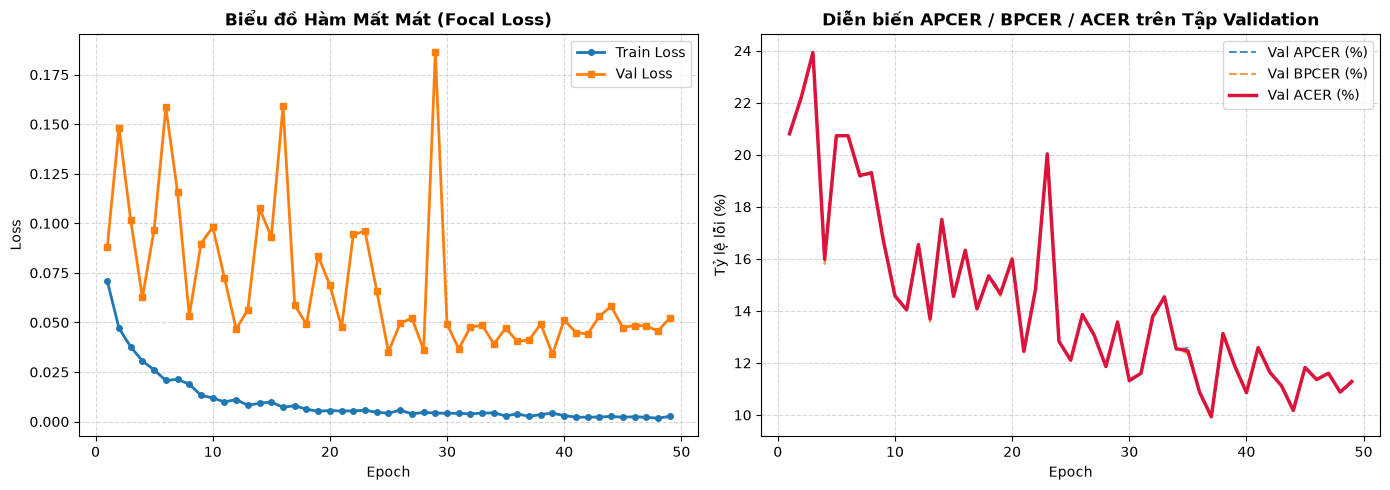

📂 Đã nạp Best Model 1 (từ Epoch 37) | Ngưỡng tối ưu từ tập Val (τ*): 0.3877



================ BẢNG KẾT QUẢ ĐÁNH GIÁ CHUẨN ISO/IEC 30107-3 ================


,Tập Đánh Giá,Ngưỡng (τ),APCER (%) ↓,BPCER (%) ↓,ACER (%) ↓,EER (%) ↓,ROC-AUC (%) ↑,Accuracy (%) ↑
0,Validation (Development),0.3877 (Val EER),9.99%,9.88%,9.93%,9.93%,96.27%,90.03%
1,Test (Evaluation - Áp ngưỡng τ* từ Val),0.3877 (Cố định),9.51%,13.38%,11.44%,11.46%,95.76%,90.33%
2,Test (Evaluation - Tại ngưỡng Test EER),0.3174 (Test EER),11.46%,11.46%,11.46%,11.46%,95.76%,88.54%


In [13]:
# === CELL 12: VẼ BIỂU ĐỒ LỊCH SỬ HUẤN LUYỆN & ĐÁNH GIÁ TRÊN TẬP TEST (ISO/IEC 30107-3) ===

# 1. Vẽ biểu đồ lịch sử huấn luyện từ file CSV
if HISTORY_CSV_PATH.exists():
    hist_df = pd.read_csv(HISTORY_CSV_PATH)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Biểu đồ 1: Train Loss vs Val Loss
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker="o", markersize=4, linewidth=2)
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss", marker="s", markersize=4, linewidth=2)
    axes[0].set_title("Biểu đồ Hàm Mất Mát (Focal Loss)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend()

    # Biểu đồ 2: Các chỉ số ISO/IEC 30107-3 trên tập Val
    axes[1].plot(hist_df["epoch"], hist_df["val_APCER"] * 100, label="Val APCER (%)", linestyle="--", alpha=0.8)
    axes[1].plot(hist_df["epoch"], hist_df["val_BPCER"] * 100, label="Val BPCER (%)", linestyle="--", alpha=0.8)
    axes[1].plot(hist_df["epoch"], hist_df["val_ACER"] * 100, label="Val ACER (%)", linewidth=2.5, color="crimson")
    axes[1].set_title("Diễn biến APCER / BPCER / ACER trên Tập Validation", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tỷ lệ lỗi (%)")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "training_curves_stage1.png", dpi=150)
    plt.show()

# 2. Nạp Checkpoint tốt nhất (MODEL1_BEST_CKPT_PATH) để đánh giá trên tập Test
assert MODEL1_BEST_CKPT_PATH.exists(), f"❌ Không tìm thấy file checkpoint tại {MODEL1_BEST_CKPT_PATH}"
best_ckpt = torch.load(MODEL1_BEST_CKPT_PATH, map_location=DEVICE, weights_only=False)

eval_model = CustomFASNet(**best_ckpt["model_config"]).to(DEVICE)
if USE_CHANNELS_LAST:
    eval_model = eval_model.to(memory_format=torch.channels_last)
eval_model.load_state_dict(best_ckpt["model_state_dict"])
eval_model.eval()

# Lấy ngưỡng tối ưu (EER threshold) đã xác lập trên tập Validation tại Best Epoch
val_optimal_threshold = float(best_ckpt["val_threshold"])
print(f"📂 Đã nạp Best Model 1 (từ Epoch {best_ckpt['best_epoch']}) | Ngưỡng tối ưu từ tập Val (τ*): {val_optimal_threshold:.4f}")

# Đánh giá lại trên tập Val và đánh giá chính thức trên tập Test (7.580 ảnh)
val_final_metrics, val_y_true, val_y_prob = evaluate_model(
    eval_model, val_loader, criterion_full, fixed_threshold=val_optimal_threshold, desc="Final Val Eval"
)
test_metrics_val_thr, test_y_true, test_y_prob = evaluate_model(
    eval_model, test_loader, criterion_full, fixed_threshold=val_optimal_threshold, desc="Final Test Eval"
)
# Tính thêm bộ chỉ số tại ngưỡng EER nội tại của tập Test để tham khảo trong báo cáo nghiên cứu
test_metrics_eer_thr = evaluate_fas_predictions(test_y_true, test_y_prob, fixed_threshold=None)

# 3. Xuất bảng tổng hợp kết quả chuẩn ISO/IEC 30107-3
summary_table = pd.DataFrame([
    {
        "Tập Đánh Giá": "Validation (Development)",
        "Ngưỡng (τ)": f"{val_optimal_threshold:.4f} (Val EER)",
        "APCER (%) ↓": f"{val_final_metrics['APCER']*100:.2f}%",
        "BPCER (%) ↓": f"{val_final_metrics['BPCER']*100:.2f}%",
        "ACER (%) ↓":  f"{val_final_metrics['ACER']*100:.2f}%",
        "EER (%) ↓":   f"{val_final_metrics['EER']*100:.2f}%",
        "ROC-AUC (%) ↑": f"{val_final_metrics['AUC']*100:.2f}%",
        "Accuracy (%) ↑": f"{val_final_metrics['ACC']*100:.2f}%",
    },
    {
        "Tập Đánh Giá": "Test (Evaluation - Áp ngưỡng τ* từ Val)",
        "Ngưỡng (τ)": f"{val_optimal_threshold:.4f} (Cố định)",
        "APCER (%) ↓": f"{test_metrics_val_thr['APCER']*100:.2f}%",
        "BPCER (%) ↓": f"{test_metrics_val_thr['BPCER']*100:.2f}%",
        "ACER (%) ↓":  f"{test_metrics_val_thr['ACER']*100:.2f}%",
        "EER (%) ↓":   f"{test_metrics_val_thr['EER']*100:.2f}%",
        "ROC-AUC (%) ↑": f"{test_metrics_val_thr['AUC']*100:.2f}%",
        "Accuracy (%) ↑": f"{test_metrics_val_thr['ACC']*100:.2f}%",
    },
    {
        "Tập Đánh Giá": "Test (Evaluation - Tại ngưỡng Test EER)",
        "Ngưỡng (τ)": f"{test_metrics_eer_thr['threshold']:.4f} (Test EER)",
        "APCER (%) ↓": f"{test_metrics_eer_thr['APCER']*100:.2f}%",
        "BPCER (%) ↓": f"{test_metrics_eer_thr['BPCER']*100:.2f}%",
        "ACER (%) ↓":  f"{test_metrics_eer_thr['ACER']*100:.2f}%",
        "EER (%) ↓":   f"{test_metrics_eer_thr['EER']*100:.2f}%",
        "ROC-AUC (%) ↑": f"{test_metrics_eer_thr['AUC']*100:.2f}%",
        "Accuracy (%) ↑": f"{test_metrics_eer_thr['ACC']*100:.2f}%",
    },
])

print("\n================ BẢNG KẾT QUẢ ĐÁNH GIÁ CHUẨN ISO/IEC 30107-3 ================")
display(summary_table)

# Lưu kết quả đánh giá ra file JSON phục vụ báo cáo
with open(ARTIFACTS_DIR / "test_evaluation_stage1.json", "w", encoding="utf-8") as f:
    json.dump({
        "val_metrics": val_final_metrics,
        "test_metrics_at_val_threshold": test_metrics_val_thr,
        "test_metrics_at_test_eer": test_metrics_eer_thr,
    }, f, indent=4)

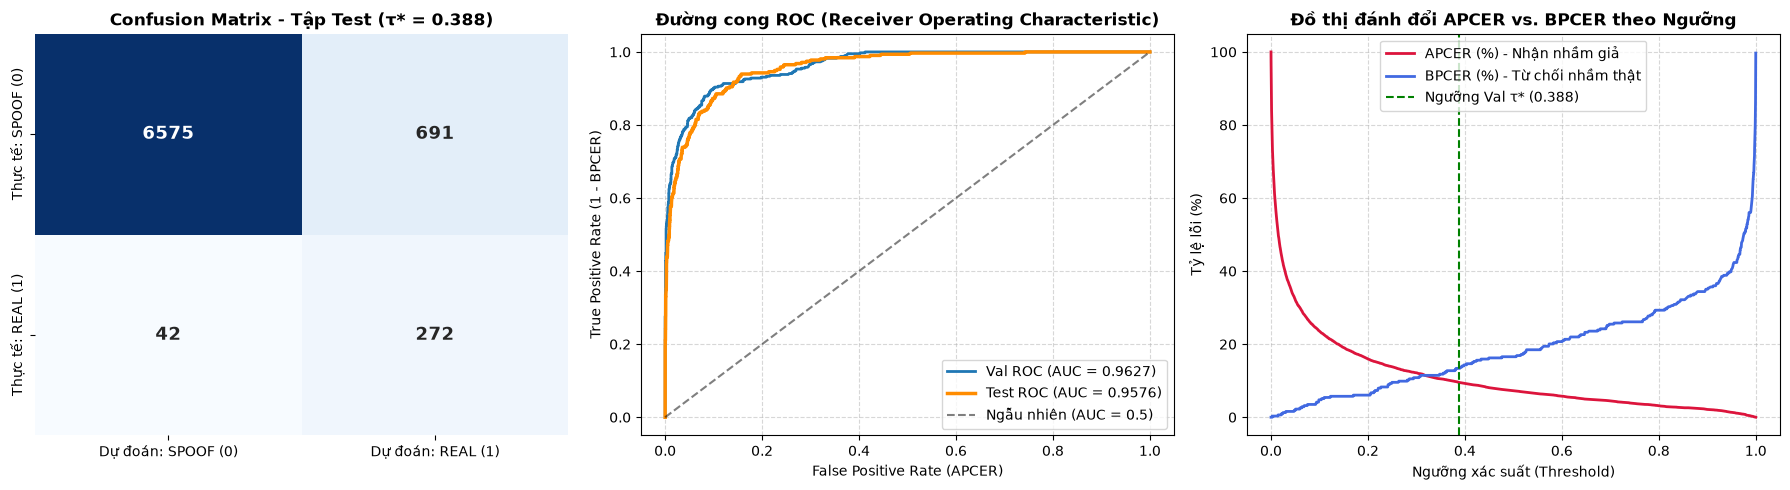


🔍 Phân tích lỗi trên Tập Test: Có 691 mẫu FP (Spoof -> Real) và 42 mẫu FN (Real -> Spoof).


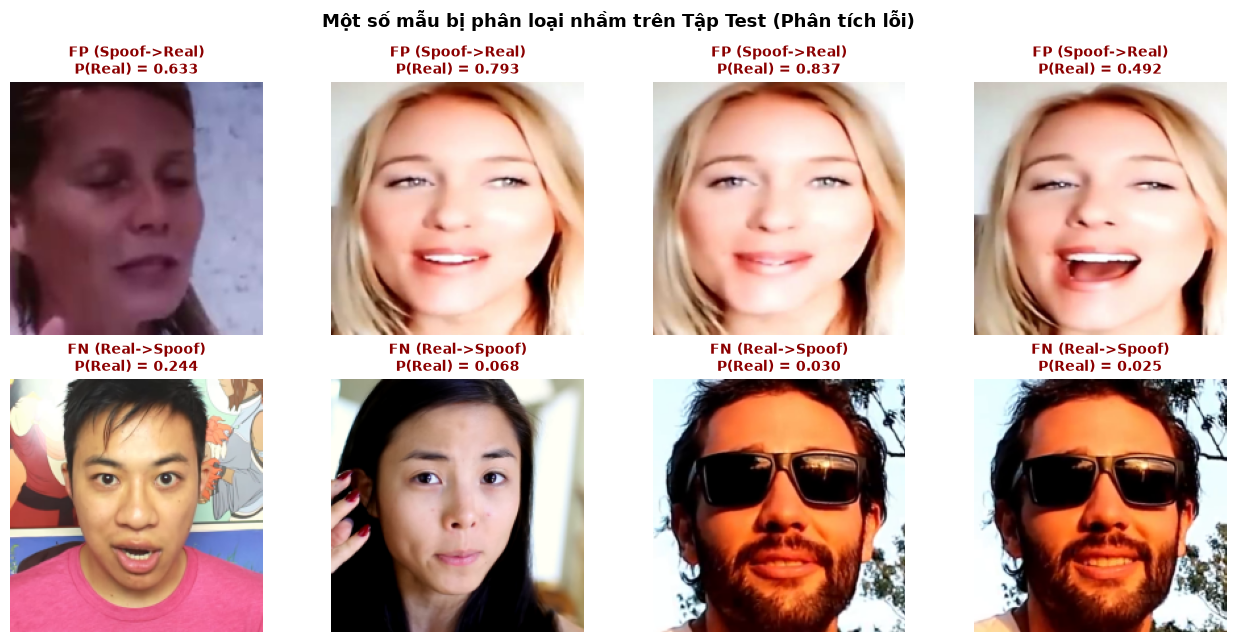

In [14]:
# === CELL 13: VẼ CONFUSION MATRIX, ĐƯỜNG CONG ROC, ĐỒ THỊ EER & PHÂN TÍCH LỖI ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix trên tập Test (tại ngưỡng τ* của Val)
cm = np.array([
    [test_metrics_val_thr["TN"], test_metrics_val_thr["FP"]],
    [test_metrics_val_thr["FN"], test_metrics_val_thr["TP"]],
])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
    xticklabels=["Dự đoán: SPOOF (0)", "Dự đoán: REAL (1)"],
    yticklabels=["Thực tế: SPOOF (0)", "Thực tế: REAL (1)"],
    annot_kws={"size": 13, "weight": "bold"},
)
axes[0].set_title(f"Confusion Matrix - Tập Test (τ* = {val_optimal_threshold:.3f})", fontsize=12, fontweight="bold")

# 2. Đường cong ROC trên tập Val & Test
fpr_val, tpr_val, _   = roc_curve(val_y_true, val_y_prob, pos_label=1)
fpr_test, tpr_test, thresholds_test = roc_curve(test_y_true, test_y_prob, pos_label=1)

axes[1].plot(fpr_val, tpr_val, label=f"Val ROC (AUC = {val_final_metrics['AUC']:.4f})", linewidth=2)
axes[1].plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {test_metrics_val_thr['AUC']:.4f})", linewidth=2.5, color="darkorange")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Ngẫu nhiên (AUC = 0.5)")
axes[1].set_title("Đường cong ROC (Receiver Operating Characteristic)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate (APCER)")
axes[1].set_ylabel("True Positive Rate (1 - BPCER)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="lower right")

# 3. Đồ thị giao cắt APCER vs BPCER theo ngưỡng trên tập Test
fnr_test = 1.0 - tpr_test
valid_mask = (thresholds_test >= 0.0) & (thresholds_test <= 1.0)
axes[2].plot(thresholds_test[valid_mask], fpr_test[valid_mask] * 100, label="APCER (%) - Nhận nhầm giả", color="crimson", linewidth=2)
axes[2].plot(thresholds_test[valid_mask], fnr_test[valid_mask] * 100, label="BPCER (%) - Từ chối nhầm thật", color="royalblue", linewidth=2)
axes[2].axvline(val_optimal_threshold, color="green", linestyle="--", label=f"Ngưỡng Val τ* ({val_optimal_threshold:.3f})")
axes[2].set_title("Đồ thị đánh đổi APCER vs. BPCER theo Ngưỡng", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Ngưỡng xác suất (Threshold)")
axes[2].set_ylabel("Tỷ lệ lỗi (%)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "test_diagnostics_stage1.png", dpi=150)
plt.show()

# --- Hiển thị trực quan một số mẫu Dự đoán Sai (False Positive & False Negative) trên Tập Test ---
test_preds = (test_y_prob >= val_optimal_threshold).astype(np.int64)
fp_indices = np.where((test_y_true == 0) & (test_preds == 1))[0]  # Spoof đoán nhầm là Real
fn_indices = np.where((test_y_true == 1) & (test_preds == 0))[0]  # Real đoán nhầm là Spoof

print(f"\n🔍 Phân tích lỗi trên Tập Test: Có {len(fp_indices)} mẫu FP (Spoof -> Real) và {len(fn_indices)} mẫu FN (Real -> Spoof).")

sample_err_indices = list(fp_indices[:4]) + list(fn_indices[:4])
if len(sample_err_indices) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
    for i, ax in enumerate(axes.flat):
        if i < len(sample_err_indices):
            idx = sample_err_indices[i]
            img_path, true_lbl = test_samples[idx]
            pred_lbl = test_preds[idx]
            prob_r   = test_y_prob[idx]

            img_rgb = decode_and_resize_single((img_path, IMG_SIZE))
            ax.imshow(img_rgb)
            err_type = "FP (Spoof->Real)" if true_lbl == 0 else "FN (Real->Spoof)"
            ax.set_title(f"{err_type}\nP(Real) = {prob_r:.3f}", color="darkred", fontsize=10, fontweight="bold")
        ax.axis("off")

    plt.suptitle("Một số mẫu bị phân loại nhầm trên Tập Test (Phân tích lỗi)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "error_analysis_stage1.png", dpi=150)
    plt.show()